# Optimization of hybrid mechanistic ML model

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
from xgboost import XGBRegressor

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 2. Configuration


In [ ]:
# File paths
QM_DATA_PATH      = r"FINAL-Reizmann_AIMNet_Gtotal_msrrho_20C_120C_all_species_new_reduced_all_methods.csv"
REIZMAN_DATA_PATH = r"Reizman_database - MECH-ML-APPEND - FINAL.xlsx"
KRAKEN_DATA_PATH  = r"KRAKEN - Ligand descriptor database.xlsx"


# Which substrate pair to optimise 
# case1: 3-bromoquinoline    + dimethylisoxazole boronate
# case2: 3-chloropyridine    + dimethylisoxazole boronate
# case3: 3-chloropyridine    + benzofuran boronate
# case4: 2-chloropyridine    + N-Boc-pyrrole boronate
OPTIMIZATION_CASE = "case4"

# Search space 
TEMPERATURE_OPTIONS      = [30, 35, 40, 45, 50, 55, 60, 65, 70,
                            75, 80, 85, 90, 95, 100, 105, 110] # °C
LIGAND_OPTIONS           = ["PCy3", "PPh3", "AmPhos", "RuPhos", "SPhos", "tBu3", "XPhos"]
CATALYST_LOADING_OPTIONS = [0.5, 1.25, 2.5, 5.0] # mol% 
TIME_OPTIONS             = [60, 150, 300, 600, 900]  # seconds: 1, 2.5, 5, 10, 15 minutes

# Random search settings 
N_RANDOM_SAMPLES = 2380 # All combinations (17x7x4x5)
TOP_N_RESULTS    = 20


## 3. Physical Constants and Reaction Dictionaries

In [ ]:
# Physical constants
R   = 8.3145        # J mol⁻¹ K⁻¹
k_B = 1.380649e-23  # J K⁻¹
h   = 6.62607015e-34  # J s

# Substrate / boronate pairings per case
dict_tm_case = {
    'case1': ('3_bromoquinoline',
              'BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole-4-boronic_acid',
              'BPinAr_compound_2_as_BPin_35-dimethylisoxazole-4-boronate'),
    'case2': ('3_chloropyridine',
              'BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole-4-boronic_acid',
              'BPinAr_compound_2_as_BPin_35-dimethylisoxazole-4-boronate'),
    'case3': ('3_chloropyridine',
              'BOH2Ar_compound_6_benzofuran-2-boronic_acid',
              'BPinAr_compound_6_benzofuran-2-boronate'),
    'case4': ('2_chloropyridine',
              'BOH2Ar_compound_9_as_BOH2_1-Boc-pyrrole-2-boronic_acid',
              'BPinAr_compound_9_as_BPin_1-Boc-pyrrole-2-boronate'),
}

# Ligand name → SMILES (used to look up KRAKEN descriptors)
# Verify these SMILES match exactly what is in your KRAKEN database
LIGAND_SMILES = {
    'XPhos':   'CC(C)c1cc(C(C)C)c(-c2ccccc2P(C2CCCCC2)C2CCCCC2)c(C(C)C)c1',
    'SPhos':   'COc1cccc(OC)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1',
    'RuPhos':  'CC(C)Oc1cccc(OC(C)C)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1',
    'PCy3':    'C1CCC(P(C2CCCCC2)C2CCCCC2)CC1',
    'PPh3':    'c1ccc(P(c2ccccc2)c2ccccc2)cc1',
    'tBu3':    'CC(C)(C)P(C(C)(C)C)C(C)(C)C',
    'AmPhos':  'CN(C)c1ccc(P(C2CCCCC2)C2CCCCC2)cc1',
}

# KRAKEN descriptor columns to use (must match selected_ligand_descriptor_list in XGB notebook)
SELECTED_LIGAND_DESCRIPTORS = [
    'sphericity_boltz',
    'vbur_vbur_boltz',
    'sterimol_burB5_boltz',
    'fmo_eta_boltz',
    'fmo_omega_boltz',
    'fukui_m_boltz',
]


## 4. Helper Functions


In [39]:
def get_G(df, species_name, temperature_C):
    """Look up the free energy G for a species at a given temperature."""
    row = df[(df["species_name"] == species_name) & (df["temperature_C"] == temperature_C)]
    if row.empty:
        raise ValueError(f"Species {species_name!r} not found at {temperature_C} °C")
    return row["G_total_wb97mv_plus_Gcorr_plus_SMDTHF_kcal_mol"].values[0]

# With flexible column name
def get_G_PdLArOH(df, species_name, temperature_C, column_name):
        row = df[(df["PdLArOH_species"] == species_name) & (df["temperature_C"] == temperature_C)]
        if row.empty:
            raise ValueError(f"Species {species_name!r} not found at {temperature_C} C")
        return row[column_name].values[0]

def get_G_flexible(df, species_name, temperature_C, column_name):
    row = df[(df["species"] == species_name) & (df["temperature_C"] == temperature_C)]
    if row.empty:
        raise ValueError(f"Species {species_name!r} not found at {temperature_C} C")
    return row[column_name].values[0]

def calc_rate_eyring(deltaG_kcal, T_C):
    T_K = T_C + 273.15
    deltaG_J = deltaG_kcal * 4184.0
    rate = (k_B * T_K / h) * np.exp(-deltaG_J / (R * T_K))
    return rate

def get_OA_barriers(df_QM, substrate, ligand, T):
    """Oxidative addition barrier and absolute TS energy."""
    if substrate == "3_bromoquinoline":
        substrate_capitalized = "3_Bromoquinoline"
    elif substrate == "2_chloropyridine":
        substrate_capitalized = "2_chloropyridine"
        substrate = "2_chloropyridine_concerted"
    else:
        substrate_capitalized = substrate

    G_PdL      = get_G(df_QM, f"PdL_Mono_{ligand}", T)
    G_Sub      = get_G(df_QM, f"Substrate_Reizman_{substrate_capitalized}", T)
    G_OA_react = get_G(df_QM, f"OA_reactant_{substrate}_{ligand}", T)
    G_OA_TS    = get_G(df_QM, f"OA_TS_{substrate}_{ligand}", T)
    G_OA_prod  = get_G(df_QM, f"OA_product_{substrate}_{ligand}", T)

    G_ref   = G_PdL + G_Sub
    dG_TS   = G_OA_TS   - G_ref
    dG_react = G_OA_react - G_ref
    return max(dG_TS, dG_TS - dG_react), G_OA_TS

def get_TM_barriers(df_QM, case, ligand, T):
    """Transmetalation barrier and absolute TS energy."""
    substrate = dict_tm_case[case][0]
    if substrate == "3_bromoquinoline":
        substrate_capitalized = "3_Bromoquinoline"
    elif substrate == "2_chloropyridine":
        substrate_capitalized = "2_chloropyridine"
        substrate = "2_chloropyridine_concerted"
    else:
        substrate_capitalized = substrate

    G_PdLArOH     = get_G(df_QM, f"PdLArOH_{substrate}_{ligand}", T)
    G_BOH2Ar      = get_G(df_QM, dict_tm_case[case][1], T)
    G_TM_react_10 = get_G(df_QM, f"TM_reactant_{case}_{ligand}_as_10", T)
    G_TM_react    = get_G(df_QM, f"TM_reactant_{case}_{ligand}", T)
    G_TM_TS       = get_G(df_QM, f"TM_TS_{case}_{ligand}", T)

    G_ref    = G_PdLArOH + G_BOH2Ar
    dG_TS    = G_TM_TS       - G_ref
    dG_react = G_TM_react    - G_ref
    dG_r10   = G_TM_react_10 - G_ref
    return max(dG_TS, dG_TS - dG_react, dG_TS - dG_r10), G_TM_TS

def get_OA_TS_absolute(substrate, ligand, case, T):
    substrate = dict_tm_case[case][0]
    if substrate == "3_bromoquinoline":
        substrate_capitalized = "3_Bromoquinoline"
    elif substrate == "2_chloropyridine":
        substrate_capitalized = "2_chloropyridine"
        substrate = "2_chloropyridine_concerted"
    else:
        substrate_capitalized = substrate 

    G_OA_TS = get_G(df_QM, f"OA_TS_{substrate}_{ligand}", T)

    return G_OA_TS

def get_TM_TS_absolute(substrate, ligand, case, T):
    substrate = dict_tm_case[case][0]
    if substrate == "3_bromoquinoline":
        substrate_capitalized = "3_Bromoquinoline"
    elif substrate == "2_chloropyridine":
        substrate_capitalized = "2_chloropyridine"
        substrate = "2_chloropyridine_concerted"
    else:
        substrate_capitalized = substrate
    
    G_TM_TS = get_G(df_QM, f"TM_TS_{case}_{ligand}", T)

    return G_TM_TS 

def get_TM_dehydration_barrier(df_QM, case, ligand, T):
    """Pinacol boronate dehydration barrier (0 for cases 3 and 4)."""
    if case in ('case3', 'case4'):
        return 0.0

    substrate = dict_tm_case[case][0]
    if substrate == "3_bromoquinoline":
        substrate_capitalized = "3_Bromoquinoline"
    elif substrate == "2_chloropyridine":
        substrate_capitalized = "2_chloropyridine"
        substrate = "2_chloropyridine_concerted"
    else:
        substrate_capitalized = substrate

    G_PdLArOH  = get_G(df_QM, f"PdLArOH_{substrate}_{ligand}", T)
    G_pinacol  = get_G(df_QM, "Pinacol", T)
    G_TM_react = get_G(df_QM, f"TM_reactant_{case}_{ligand}", T)
    G_Bpin     = get_G(df_QM, dict_tm_case[case][2], T)
    G_H2O      = get_G(df_QM, "H2O", T)
    G_TM_TS    = get_G(df_QM, f"TM_TS_{case}_{ligand}", T)

    G_ref    = G_PdLArOH + G_Bpin + 2 * G_H2O
    dG_react = (G_TM_react + G_pinacol) - G_ref
    dG_TS    = (G_TM_TS   + G_pinacol) - G_ref
    return max(dG_TS, dG_TS - dG_react)

def get_aryl_halide_absolute(substrate, ligand, case, T):
    substrate = dict_tm_case[case][0]
    if substrate == "3_bromoquinoline":
        substrate_capitalized = "3_Bromoquinoline"
    elif substrate == "2_chloropyridine":
        substrate_capitalized = "2_chloropyridine"
        substrate = "2_chloropyridine_concerted"
    else:
        substrate_capitalized = substrate 

    G_Substrate = get_G(df_QM, f"Substrate_Reizman_{substrate_capitalized}", T)

    return G_Substrate

def get_OA_rate(substrate, ligand, case, T): 
    OA_barrier, _ = get_OA_barriers(df_QM, substrate, ligand, T)
    OA_rate = calc_rate_eyring(OA_barrier, T)
    return OA_rate

# Calculates rate constant of the forward reaction for TM
def get_TM_rate(substrate, ligand, case, T):
    TM_barrier, _ = get_TM_barriers(df_QM, case, ligand, T)
    TM_rate = calc_rate_eyring(TM_barrier, T)
    return TM_rate

def get_dG_PdLArOH(substrate, ligand, case, T):
    substrate = dict_tm_case[case][0]
    if substrate == "3_bromoquinoline":
        substrate_capitalized = "3_Bromoquinoline"
    elif substrate == "2_chloropyridine":
        substrate_capitalized = "2_chloropyridine"
        substrate = "2_chloropyridine_concerted"
    else:
        substrate_capitalized = substrate 

    dG_PdLArOH_X = get_G_PdLArOH(df_ggw_reactions_all_species, f"PdLArOH_{substrate}_{ligand}", T, "deltaG_1M_kcal_mol_wb97mv_SMDTHF")

    return dG_PdLArOH_X

def get_G_precatalyst(substrate, ligand, case, T, cat_gen):
    substrate = dict_tm_case[case][0]
    if substrate == "3_bromoquinoline":
        substrate_capitalized = "3_Bromoquinoline"
    elif substrate == "2_chloropyridine":
        substrate_capitalized = "2_chloropyridine"
        substrate = "2_chloropyridine_concerted"
    else:
        substrate_capitalized = substrate 

    if cat_gen == "G3":
        if ligand == "RuPhos" or ligand == "SPhos":
            G_precatalyst = get_G_flexible(df_precat, f"{cat_gen}_{ligand}_{cat_gen}_OMs_from_G2", T, "Gtotal_wB97MV_gas_SPE_AIMNet2PD_msRRHO_Gsolv_THF_kcal_mol")
        else:
            G_precatalyst = get_G_flexible(df_precat, f"{cat_gen}_Mono_{ligand}_{cat_gen}_OMs_fromG2", T, "Gtotal_wB97MV_gas_SPE_AIMNet2PD_msRRHO_Gsolv_THF_kcal_mol")
    elif cat_gen == "G2":
            G_precatalyst = get_G_flexible(df_precat, f"{cat_gen}_Mono_{ligand}_{cat_gen}_fixedPdN", T, "Gtotal_wB97MV_gas_SPE_AIMNet2PD_msRRHO_Gsolv_THF_kcal_mol")
    
    return G_precatalyst

def compute_all_descriptors(df_QM, ligand, case, T):
    """
    Compute the full set of mechanistic descriptors for one (ligand, case, T) combination.
    Returns a dict whose keys match the feature columns used in the XGBoost model.
    """
    substrate = dict_tm_case[case][0]
    sub_cap   = ("3_Bromoquinoline" if substrate == "3_bromoquinoline" else substrate)

    dG_OA, _   = get_OA_barriers(df_QM, substrate, ligand, T)
    G_OA_TS = get_OA_TS_absolute(substrate, ligand, case, T)
    dG_TM, _ =  get_TM_barriers(df_QM, case, ligand, T)
    G_TM_TS = get_TM_TS_absolute(substrate, ligand, case, T)
    dG_dehyd          = get_TM_dehydration_barrier(df_QM, case, ligand, T)
    G_Sub             = get_aryl_halide_absolute(substrate, ligand, case, T)
    G_boron           = get_G(df_QM, dict_tm_case[case][1], T) # no specif function defined for this
    k_OA              = get_OA_rate(substrate, ligand, case, T)
    k_TM              = get_TM_rate(substrate, ligand, case, T)
    dG_PdLArOH       = get_dG_PdLArOH(substrate, ligand, case, T)
    G_precatalyst = get_G_precatalyst(substrate, ligand, case, T , cat_gen="G3")

    return {
        'dG_OA':             dG_OA,
        'dG_TM':             dG_TM,
        'G_OA_TS':           G_OA_TS,
        'G_TM_TS':           G_TM_TS,
        'dG_boron_hydrolysis': dG_dehyd,
        'G_Substrate':       G_Sub,
        'G_boron_species':   G_boron,
        'k_OA':              k_OA,
        'k_TM':              k_TM,
        'dG_PdLArOH':        dG_PdLArOH,
        'G_precatalyst':     G_precatalyst,
    }


## 5. Load Data

In [ ]:
df_QM     = pd.read_csv(QM_DATA_PATH)
df_train  = pd.read_excel(REIZMAN_DATA_PATH)
df_kraken = pd.read_excel(KRAKEN_DATA_PATH, sheet_name='dft_targets_SI')
df_ggw_reactions_all_species = pd.read_csv(r"Final_equilibria\Final_equilibria\FINAL_GGW_reactions_r2scan3c_RRHO_20C_120C_FROM_ALL_SPECIES.csv")
df_precat = pd.read_csv(r"final_precatalysts\final_precatalysts\tables\Precat_Gtotal_msrrho_20C_120C_all_species_wide_kcalmol.csv")

print(f"QM data:        {df_QM.shape[0]:>5} rows")
print(f"Training data:  {df_train.shape[0]:>5} rows")
print(f"KRAKEN data:    {df_kraken.shape[0]:>5} rows")
print(f"GGW reactions data: {df_ggw_reactions_all_species.shape[0]:>5} rows")
print(f"Precatalyst data: {df_precat.shape[0]:>5} rows")

QM data:        44844 rows
Training data:    367 rows
KRAKEN data:     1540 rows
GGW reactions data:  3838 rows
Precatalyst data:  1818 rows


## 6. Preprocess Training Data


In [ ]:
import joblib 
xgb_model     = joblib.load(r"MECH-ML-XGB-MODEL-FINAL.pkl")
FEATURE_NAMES = joblib.load(r"MECH-ML-XGB-FEATURE-NAMES-FINAL.pkl")
X_train = joblib.load(r"MECH-ML-XGB-XTRAIN-FINAL.pkl")

## 8. Generate Virtual Candidates and Compute Descriptors


In [43]:
from itertools import product

all_combos = list(product(TEMPERATURE_OPTIONS, LIGAND_OPTIONS,
                          CATALYST_LOADING_OPTIONS, TIME_OPTIONS))
print(f"Total combinations to evaluate: {len(all_combos)}")

# Subsample if the space is larger than N_RANDOM_SAMPLES
if len(all_combos) > N_RANDOM_SAMPLES:
    idx_sample = np.random.choice(len(all_combos), size=N_RANDOM_SAMPLES, replace=False)
    combos_to_eval = [all_combos[i] for i in idx_sample]
    print(f"Random subsampling to {N_RANDOM_SAMPLES} candidates")
else:
    combos_to_eval = all_combos
    print("Evaluating all combinations exhaustively")

candidates = []
skipped    = []

for T, ligand, cat_loading, time_s in combos_to_eval:
    try:
        desc = compute_all_descriptors(df_QM, ligand, OPTIMIZATION_CASE, T)
        candidates.append({
            'temp_c': T, 'ligand': ligand,
            'cat_loading': cat_loading, 'time_s': time_s,
            **desc
        })
    except ValueError as e:
        skipped.append((T, ligand, str(e)))

print(f"\nDescriptors computed: {len(candidates)}")
print(f"Skipped (missing QM data): {len(skipped)}")
if skipped:
    print("  Skipped entries:", skipped[:5])


Total combinations to evaluate: 2380
Evaluating all combinations exhaustively

Descriptors computed: 2380
Skipped (missing QM data): 0


In [50]:
# # Saving the canditates to a CSV so they can be loaded easily later on
# df_candidates = pd.DataFrame(candidates)
# df_candidates.to_csv(f"CANDIDATES_{OPTIMIZATION_CASE}.csv", index=False)
# print(f"Saved {len(df_candidates)} candidates to CANDIDATES_{OPTIMIZATION_CASE}.csv")

# Load candidates from CSV 
df_candidates_loaded = pd.read_csv(f"CANDIDATES_{OPTIMIZATION_CASE}.csv")
print(f"Loaded {len(df_candidates_loaded)} candidates")

Loaded 2380 candidates


## 9. Predict Yields for All Candidates

In [44]:
df_cand = pd.DataFrame(candidates)

# Build feature matrix in the exact same column order as training
X_cand = df_cand[FEATURE_NAMES].copy()
df_cand['predicted_yield'] = xgb_model.predict(X_cand)

print(f"Predicted yield range: {df_cand['predicted_yield'].min():.1f}% – {df_cand['predicted_yield'].max():.1f}%")
print(f"Mean predicted yield:  {df_cand['predicted_yield'].mean():.1f}%")


Predicted yield range: -5.0% – 99.8%
Mean predicted yield:  40.6%


## 10. Domain of Applicability Check

In [45]:
scaler     = StandardScaler().fit(X_train[FEATURE_NAMES].values.astype(float))
X_tr_sc    = scaler.transform(X_train[FEATURE_NAMES].values.astype(float))
X_ca_sc    = scaler.transform(X_cand.values.astype(float))

# Mean distance to 5 nearest training neighbours
dist_tr    = np.sort(cdist(X_tr_sc, X_tr_sc), axis=1)[:, 1:6].mean(axis=1)
dist_ca    = np.sort(cdist(X_ca_sc, X_tr_sc), axis=1)[:, :5].mean(axis=1)

threshold  = np.percentile(dist_tr, 95)
df_cand['nn_distance']   = dist_ca
df_cand['out_of_domain'] = dist_ca > threshold

n_ood = df_cand['out_of_domain'].sum()
print(f"Domain threshold (95th pct of training): {threshold:.3f}")
print(f"Out-of-domain candidates: {n_ood} / {len(df_cand)} ({100*n_ood/len(df_cand):.1f}%)")


Domain threshold (95th pct of training): 2.693
Out-of-domain candidates: 1186 / 2380 (49.8%)


## 11. Results

In [46]:
top = (df_cand
       .sort_values('predicted_yield', ascending=False)
       .head(TOP_N_RESULTS)
       .reset_index(drop=True))

display_cols = ['temp_c', 'ligand', 'cat_loading', 'time_s',
                'predicted_yield',
              #    'nn_distance', 'out_of_domain'
              ]

print(f"Top {TOP_N_RESULTS} predicted conditions — {OPTIMIZATION_CASE}")
print("=" * 75)
print(top[display_cols].to_string(index=True))

ood = top['out_of_domain'].sum()
if ood:
    print(f"\n⚠  {ood} of the top {TOP_N_RESULTS} candidates are outside the training domain.")
    print("   Their predicted yields may be less reliable.")


Top 20 predicted conditions — case4
    temp_c ligand  cat_loading  time_s  predicted_yield
0       75  XPhos          2.5     300        99.820000
1       80  XPhos          2.5     300        99.550552
2       75  XPhos          2.5     600        99.029129
3       75  XPhos          2.5     900        99.029129
4       80  XPhos          2.5     600        98.719521
5       80  XPhos          2.5     900        98.719521
6       85  XPhos          2.5     300        98.699936
7       85  XPhos          2.5     600        97.993088
8       85  XPhos          2.5     900        97.993088
9       75  XPhos          5.0     300        97.643387
10      80  XPhos          5.0     300        97.430954
11      75  XPhos          5.0     600        96.746490
12      75  XPhos          5.0     900        96.746490
13      85  XPhos          5.0     300        96.531250
14      80  XPhos          5.0     900        96.493896
15      80  XPhos          5.0     600        96.493896
16      75  

## 12. Visualisation

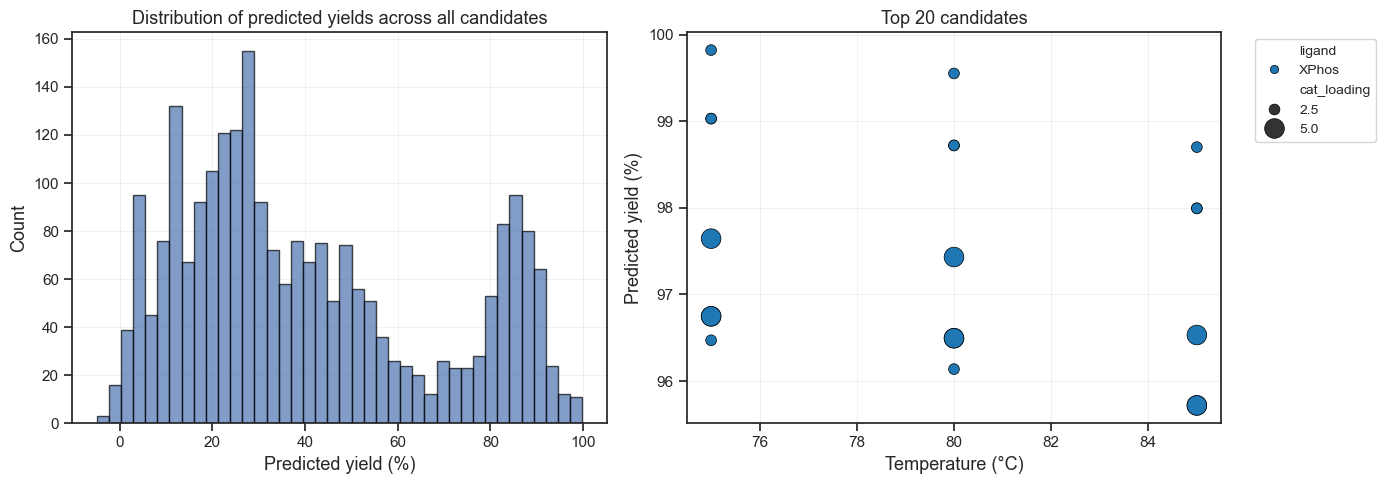

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="ticks")

# Distribution of all predicted yields
axes[0].hist(df_cand['predicted_yield'], bins=40, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Predicted yield (%)', fontsize=13)
axes[0].set_ylabel('Count', fontsize=13)
axes[0].set_title('Distribution of predicted yields across all candidates', fontsize=13)
axes[0].grid(True, linewidth=0.5, alpha=0.4)

# Top conditions coloured by ligand
palette = sns.color_palette("tab10", n_colors=len(top['ligand'].unique()))
sns.scatterplot(data=top, x='temp_c', y='predicted_yield',
                hue='ligand', size='cat_loading', sizes=(60, 200),
                palette=palette, ax=axes[1], edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Temperature (°C)', fontsize=13)
axes[1].set_ylabel('Predicted yield (%)', fontsize=13)
axes[1].set_title(f'Top {TOP_N_RESULTS} candidates', fontsize=13)
axes[1].grid(True, linewidth=0.5, alpha=0.4)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()


## 13. Save Results

In [ ]:
out_path = f"OPTIMIZATION-{OPTIMIZATION_CASE}-PREDICTIONS.csv"
df_cand.sort_values('predicted_yield', ascending=False).to_csv(out_path, index=False)
print(f"Full results saved to: {out_path}")


Full results saved to: OPTIMIZATION_case4.csv
